# Joint Constraints
In this notebook, after having computed $\chi_r^2$ surfaces for both the GW method ($z-d_L$ relation) and the long sgrb data ($E_\text{peak}-E_\text{iso}$ relation). We will now sum both surfaces in other to obtains a combined constraint of the $\Omega_m, \Omega_\Lambda$ cosmological parameters.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

GW_CHI_SQUARE = np.load('../data/GW_chi_surface.npy')
GW_MASK = np.load('../data/GW_mask.npy')

gw_chi_surface = np.ma.array(GW_CHI_SQUARE, mask=GW_MASK)
gw_min = np.min(gw_chi_surface)

SGRB_CHI_SQUARE = np.load('../data/LGRB_chi_surface.npy')
SGRB_MASK = np.load('../data/LGRB_mask.npy')

sgrb_chi_surface = np.ma.array(SGRB_CHI_SQUARE, mask=SGRB_MASK)
sgrb_min = np.min(sgrb_chi_surface)

print(gw_chi_surface.shape, gw_min)
print(sgrb_chi_surface.shape, sgrb_min)

(100, 100) 0.4622296209402596
(100, 100) 74.94785615313285


Best_fit GW: Om=0.330	 Ode=0.906
Best_fit sgrb: Om=0.215	 Ode=1.021


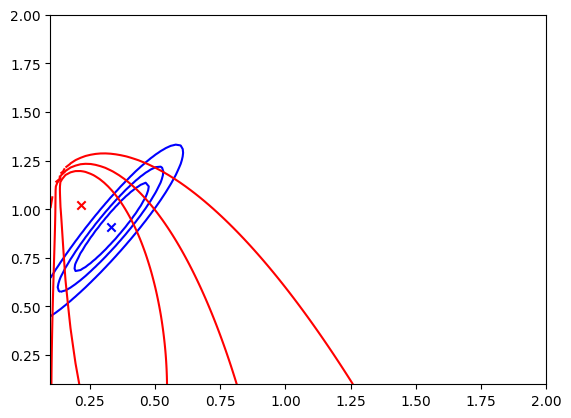

In [3]:
# the best fit parameters (at least for GW) are highly dependent on the grid parameters. changing the first number from 0.0 to 0.1 change the best fit parameters from (0.242, 0.848) to (0.330, 0.906)
Om = np.linspace(0.1, 2.0, 100)
Ode = np.linspace(0.1, 2.0, 100)

i1, i2 = np.unravel_index(np.argmin(gw_chi_surface), gw_chi_surface.shape)
Om_gw, Ode_gw = Om[i1], Ode[i2]

i1, i2 = np.unravel_index(np.argmin(sgrb_chi_surface), sgrb_chi_surface.shape)
Om_sgrb, Ode_sgrb = Om[i1], Ode[i2]
print(f'Best_fit GW: Om={Om_gw:.3f}\t Ode={Ode_gw:.3f}')
print(f'Best_fit sgrb: Om={Om_sgrb:.3f}\t Ode={Ode_sgrb:.3f}')

plt.figure()
plt.contour(Om, Ode, gw_chi_surface.T, levels=[gw_min+2.3, gw_min+4.61, gw_min+9.21], colors='blue')
plt.contour(Om, Ode, sgrb_chi_surface.T, levels=[sgrb_min+2.3, sgrb_min+4.61, sgrb_min+9.21], colors='red')
plt.scatter(Om_gw, Ode_gw, c='b', label=f'GW: {Om_gw:.3f} {Ode_gw:.3f}', marker='x')
plt.scatter(Om_sgrb, Ode_sgrb, c='r', label=f'sgrb: {Om_sgrb:.3f} {Ode_sgrb:.3f}', marker='x')

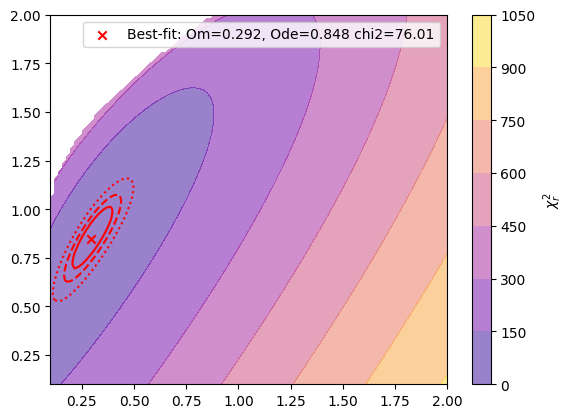

In [4]:
joint_surface = gw_chi_surface + sgrb_chi_surface
jmin = np.min(joint_surface)
i1, i2 = np.unravel_index(np.argmin(joint_surface), joint_surface.shape)
Omj, Odej = Om[i1], Ode[i2]

plt.figure()
im = plt.contourf(Om, Ode, joint_surface.T, cmap='plasma', alpha=0.5)
plt.colorbar(im, label=r'$\chi_r^2$')
plt.contour(Om, Ode, joint_surface.T, levels=[jmin+2.3, jmin+4.61, jmin+9.21], colors='red', linestyles=['solid', 'dashed', 'dotted'])
plt.scatter(Omj, Odej, c='r', marker='x', label=f'Best-fit: Om={Omj:.3f}, Ode={Odej:.3f} chi2={jmin:.2f}')
plt.legend()

/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_85941/2686399028.py:2: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(Om, Ode, gw_chi_surface.T, levels=[gw_min+2.3, gw_min+4.61, gw_min+9.21], colors='cyan', linestyles=['solid', 'dashed', 'dotted'], label='GW')
/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_85941/2686399028.py:3: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(Om, Ode, sgrb_chi_surface.T, levels=[sgrb_min+2.3, sgrb_min+4.61, sgrb_min+9.21], colors='deeppink', linestyles=['solid', 'dashed', 'dotted'], label='sgrb')
/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_85941/2686399028.py:7: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(Om, Ode, joint_surface.T, cmap='plasma', alpha=0.8, label='sgrb+GW')
/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_85941/2686399028.py:8: UserWarning: Adding colorbar to a different Figure <Figu

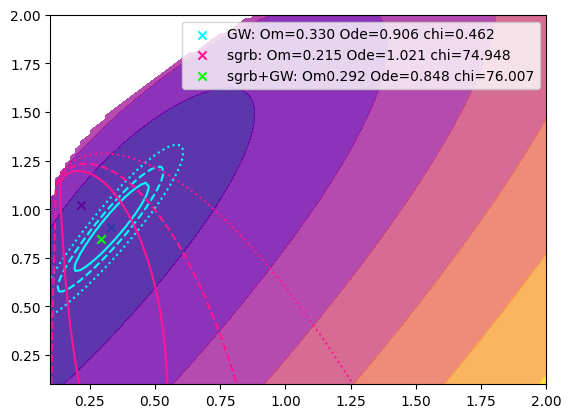

In [5]:
plt.figure()
plt.contour(Om, Ode, gw_chi_surface.T, levels=[gw_min+2.3, gw_min+4.61, gw_min+9.21], colors='cyan', linestyles=['solid', 'dashed', 'dotted'], label='GW')
plt.contour(Om, Ode, sgrb_chi_surface.T, levels=[sgrb_min+2.3, sgrb_min+4.61, sgrb_min+9.21], colors='deeppink', linestyles=['solid', 'dashed', 'dotted'], label='sgrb')
plt.scatter(Om_gw, Ode_gw, c='cyan', label=f'GW: Om={Om_gw:.3f} Ode={Ode_gw:.3f} chi={gw_min:.3f}', marker='x')
plt.scatter(Om_sgrb, Ode_sgrb, c='deeppink', label=f'sgrb: Om={Om_sgrb:.3f} Ode={Ode_sgrb:.3f} chi={sgrb_min:.3f}', marker='x')

plt.contourf(Om, Ode, joint_surface.T, cmap='plasma', alpha=0.8, label='sgrb+GW')
plt.colorbar(im, label=r'sgrb-GW $\chi_r^2$')
plt.scatter(Omj, Odej, marker='x', color='lime', label=f'sgrb+GW: Om{Omj:.3f} Ode={Odej:.3f} chi={jmin:.3f}')

plt.legend()

/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_85941/3603046048.py:2: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(Om, Ode, gw_chi_surface.T, levels=[gw_min+2.3, gw_min+4.61, gw_min+9.21], colors='b', linestyles=['solid', 'dashed', 'dotted'], label='GW', alpha=0.2)
/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_85941/3603046048.py:5: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(Om, Ode, sgrb_chi_surface.T, levels=[sgrb_min+2.3, sgrb_min+4.61, sgrb_min+9.21], colors='r', linestyles=['solid', 'dashed', 'dotted'], label='sgrb', alpha=0.2)
/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_85941/3603046048.py:8: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contourf(Om, Ode, joint_surface.T, cmap='plasma', label='GRB+GW', levels=[jmin, jmin+2.3, jmin+4.61, jmin+9.21])
/var/folders/lq/7_q5kjhn1pzgzvpl0fk8y5mc0000gp/T/ipykernel_85941/3603046048.py:9: UserWarni

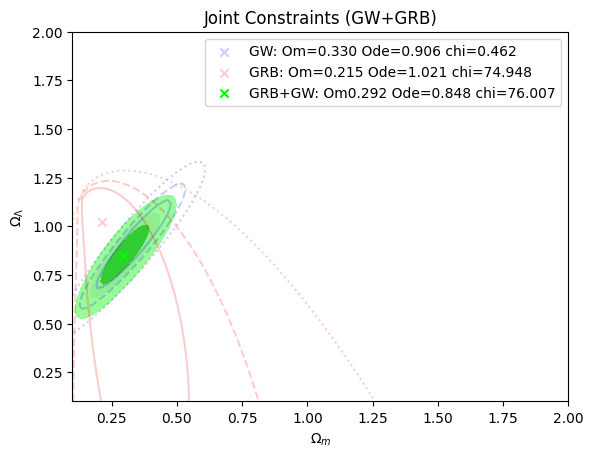

In [6]:

plt.figure()
plt.contour(Om, Ode, gw_chi_surface.T, levels=[gw_min+2.3, gw_min+4.61, gw_min+9.21], colors='b', linestyles=['solid', 'dashed', 'dotted'], label='GW', alpha=0.2)
plt.scatter(Om_gw, Ode_gw, c='b', label=f'GW: Om={Om_gw:.3f} Ode={Ode_gw:.3f} chi={gw_min:.3f}', marker='x', alpha=0.2)

plt.contour(Om, Ode, sgrb_chi_surface.T, levels=[sgrb_min+2.3, sgrb_min+4.61, sgrb_min+9.21], colors='r', linestyles=['solid', 'dashed', 'dotted'], label='sgrb', alpha=0.2)
plt.scatter(Om_sgrb, Ode_sgrb, c='r', label=f'GRB: Om={Om_sgrb:.3f} Ode={Ode_sgrb:.3f} chi={sgrb_min:.3f}', marker='x', alpha=0.2)

plt.contourf(Om, Ode, joint_surface.T, cmap='plasma', label='GRB+GW', levels=[jmin, jmin+2.3, jmin+4.61, jmin+9.21])
plt.contourf(Om, Ode, joint_surface.T, colors = ['limegreen', 'lightgreen', 'palegreen'], label='GRB+GW', levels=[jmin, jmin+2.3, jmin+4.61, jmin+9.21])
plt.scatter(Omj, Odej, marker='x', color='lime', label=f'GRB+GW: Om{Omj:.3f} Ode={Odej:.3f} chi={jmin:.3f}')

plt.xlabel(r'$\Omega_m$')
plt.ylabel(r'$\Omega_\Lambda$')
plt.title(r'Joint Constraints (GW+GRB)')
plt.legend()